## Intercomparison of inverse modelling results

This notebook contains options to plot and compare results from different inverse models. The following variables can be investigated:

- Posterior and prior country fluxes, total from all sectors, and respective uncertainties
- Observed and posterior/prior modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior bias mole fractions
- Posterior and prior mole fractions from the outer regions
- Observed repeatability/variability, model and total uncertainties
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Input data:

- Flux and concentration netCDF files with model outputs
- json files with models, sites and species information
- (optional) netCDF file with country fluxes from bottom-up inventory
- (optional) netCDF file with baseline timestamps

Please refer to the User Guide for information on files format, filename convention and folder structure.

### Notebook setup:

1. Decide the verbosity level by assigning the logging level to `logging.INFO` or `logging.WARNING`.

2. Edit the `data_dir` to point towards where the model output is.

3. Set `presentation_mode` to `True`/`False` to use big font sizes (recommended for slides) or small font sizes (recommended for text documents). 

4. Update the `experiments` dictionary so that each key points towards the models you want to plot.

5. Run the cell below, before running any of the plotting code.

In [1]:
%load_ext autoreload
%autoreload 2
import logging
logging.basicConfig(level=logging.WARNING)

from fluxy.config import set_print_settings
from fluxy.io import read_config_files

### Path to results directory 
data_dir = '/data/users/alice.ramsden/h2_InTEM_output/'

### Set presentation_mode to True for bigger fonts
presentation_mode = False

### Group the models of interest in meaningful experiment names 
experiments = {'std_run'       :['InTEM_NAME_EUROPE_EDGAR_std', 'ELRIS_NAME_EUROPE_EDGAR_std', 'RHIME_NAME_EUROPE_EDGAR_std'],
               'wetcharts'     :['InTEM_NAME_EUROPE_EDGARWETCHART_31sites_std','ELRIS_NAME_EUROPE_EDGARWETCHART_31base',
                                 'RHIME_NAME_EUROPE_EDGAR-WetCHARTs_std_31sites']
              }

###################################

config_data = read_config_files()
annotate_coords = set_print_settings(presentation_mode)

### 1. Timeseries of country/region fluxes

##### Edit and run this cell to read and pre-process the data:

In [ ]:
from fluxy.io import read_model_output, read_flux_total_fgases
from fluxy.operators.select import slice_flux
from fluxy.config import set_model_colors
from fluxy.config import set_model_labels
from fluxy.operators.flux_scale_by_sector_proportions import scale_by_sector_proportions

###################################
### edit variables in this block
species = 'h2' #options for individual species, or 'all_hfc' or 'all_pfc'
models = ['InTEM_NAME_EUROPE_flatlandsea_MH',
          'InTEM_NAME_EUROPE_flatlandsea_popouterregions_MH',
          'InTEM_NAME_EUROPE_flatlandsea_manualouter_MHWB',
          'InTEM_NAME_EUROPE_flatlandsea_manualouter_100uncertUK_MHWB',
          'InTEM_NAME_EUROPE_flatlandsea_manualouter3_100uncertUK_MHWB'] #if using 'all_hfc' or 'all_pfc' use basic model names  (e.g. ['InTEM','ELRIS','RHIME']) and standard filenames (listed in config_data["models_info"]["standard_run"]["default"]) will be used for each species. 
                                #To use non standard filenames, do <model>_<config_key> : e.g. with ['ELRIS_elris-n2o'], the filenames will be looked in config_data["models_info"]["standard_run"]["elris-n2o"].
regions = ['UK','NW_EU2','CW_EU']
period = 'yearly' #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
country_flux_units_print = 'Gg yr-1' #desired units for the plot. Add "CO2-eq" to convert the mass to CO2 equivalent (e.g. "Gg CO2-eq yr-1")
start_date = '1998-01-01' #inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
end_date = '2024-01-01' #not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year
get_labels_from_file = True # If False, uses default labels. If True, uses labels in models_info.json.
sector_file = None  # if not None, adds sector level results by scaling model totals by the sector proportions in this file. Default file: 'EUROPE_EDGAR', inside the 'sector_flux' directory
create_region_sector_totals = True #if True, uses country_fraction variable to sum spatial sector fluxes to region sector fluxes
read_standard_run = False
only_overlapping = True #if True, only uses time periods where all models have data
###################################

if 'all' in species:
    ds_all_flux_scaled = read_flux_total_fgases(data_dir,species,models,config_data,
                                                     regions,start_date,end_date,
                                                     period=period,only_overlapping=only_overlapping)
else:
    ds_all_flux = read_model_output(data_dir,"flux",species,models,config_data,period=period,read_standard_run=read_standard_run)
    ds_all_flux_scaled = slice_flux(ds_all_flux,config_data,start_date,end_date,species=species,country_flux_units_print=country_flux_units_print)

if sector_file is not None:
    ds_all_flux_scaled = scale_by_sector_proportions(data_dir=data_dir,ds_all=ds_all_flux_scaled,
                                                            species=species,
                                                            country_flux_units_print=country_flux_units_print,
                                                            config_data=config_data,regions=regions,
                                                            sector_file=sector_file,create_region_sector_totals=create_region_sector_totals)   

model_colors = set_model_colors(models)
model_labels = set_model_labels(models,config_data,get_labels_from_file)

#### Timeseries of country fluxes:

In [ ]:
from fluxy.plots.flux_timeseries import plot_country_flux

###################################
### edit variables in this block
plot_inventory = False
plot_inventory_uncertainty = [False]    #Either True/False or a list of True/False to match length of inventory_years
inventory_years = None #If None, plots most recent. Or can choose list of years: ['2022','2023']
inventory_filename = 'UNFCCC_inventory'   #Full filename = {inventory_filename}_{species}_{inventory_year}
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior = True #if True: plots prior as dashed lines
add_prior_unc = True #if True: plots prior uncertainty as shaded area
set_global_leg = True #If True, plots one single legend instead of one legend per subplot.
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles. Set to None for no title.
plot_separate = True #If True, includes all model results as separate lines (or insert a list of boolean of the same length as models to specify which models to plot)
plot_separate_unc = True #If True, includes all model uncertainty as shaded areas
plot_combined = False #If True, combined results, averaged from all models (or insert a list of boolean of the same length as models to specify which models to combine)
combined_models_dict = None #To plot multiple combined results, use (e.g.) combined_models_dict = {'NAME Mean': ['InTEM_NAME', 'ELRIS_NAME'], 'FLEXPART Mean': ['InTEM_FLEXPART', 'ELRIS_FLEXPART']} and set plot_combined = True.
plot_combined_unc = True #If True, includes combined uncertainty as shaded area
resample = None #If None, no resample is done. Else resample the data to the given period (options 'year' and 'season' for yearly and seasonal averages)
resample_uncert_correlation = False #If True, uses mean uncertainty during resampling, if False, recalculates uncertainty assuming no correlation.
plot_resample_and_original = False #If True, plots both the resampled and original data
annex_mode = False #If True, replace the labels with more concise versions for NID Annexes.
rolling_mean = False # If True, calculates a rolling mean of the data (insert a list of boolean of the same length as models to specify the models to smooth)
sector = 'total'     # default 'total', otherwise chosen single sector plotted for all models
aggreg_month = False     # if True, plot the fluxes aggregated by month. Only work with monthly data.
xticks_at_centre = False    # if True, moves x ticks to centre of time periods
plot_grid = True    # if True, adds faint grid to the plots
add_vline = None # List of dates (str) to add vertical lines to the plots, e.g. ['2016-07-02', '2023-07-02']
secondary_units = None # If not None, e.g. 'Gg yr-1', adds a secondary y axis with these units
###################################

fig = plot_country_flux(ds_all_flux_scaled,
                        species,
                        regions,
                        config_data,
                        model_colors,
                        model_labels,
                        start_date,
                        end_date,
                        annex_mode,
                        plot_inventory,
                        plot_inventory_uncertainty,
                        inventory_years,
                        inventory_filename,
                        data_dir,
                        fix_y_axes,
                        add_prior,
                        add_prior_unc,
                        set_global_leg,
                        country_codes_as_titles=country_codes_as_titles,
                        plot_separate=plot_separate,
                        plot_separate_unc=plot_separate_unc,
                        plot_combined=plot_combined,
                        combined_models_dict = combined_models_dict,
                        plot_combined_unc=plot_combined_unc,
                        resample=resample,
                        resample_uncert_correlation=resample_uncert_correlation,
                        plot_resample_and_original=plot_resample_and_original,
                        rolling_mean=rolling_mean,
                        aggreg_month=aggreg_month,
                        xticks_at_centre=xticks_at_centre,
                        plot_grid=plot_grid,
                        add_vline=add_vline,
                        secondary_units=secondary_units,
                        return_res=True,sector=sector)

In [ ]:
output_path = '/home/users/alice.ramsden/plots/h2/inversions_no_sources_sinks/h2_UK_country_flux_flatprior_testing.png'

fig[0].savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries of sector country fluxes - as bar charts

In [ ]:
from fluxy.plots.flux_timeseries import plot_country_sector_flux_bar

###################################
### edit variables in this block
plot_region = 'UK'
plot_inventory_or_prior = 'prior'
inventory_years = None #If None, plots most recent. Or can choose list of years: ['2022','2023']
inventory_filename = 'UNFCCC_inventory'   #Full filename = {inventory_filename}_{species}_{inventory_year}
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior = True #if True: plots prior as dashed lines
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles. Set to None for no title.
resample = None #If None, no resample is done. Else resample the data to the given period (options 'year' and 'season' for yearly and seasonal averages)
resample_uncert_correlation = False #If True, uses mean uncertainty during resampling, if False, recalculates uncertainty assuming no correlation.
plot_resample_and_original = False #If True, plots both the resampled and original data
annex_mode = False #If True, replace the labels with more concise versions for NID Annexes.
rolling_mean = None ##If True, calculates a rolling mean of the data (insert a list of boolean of the same length as models to specify the models to smooth)
sectors = ['agriculture','waste','energy','industry']
###################################

fig = plot_country_sector_flux_bar(ds_all=ds_all_flux_scaled,species=species,plot_region=plot_region,
                                   config_data=config_data,model_labels=model_labels,
                                   plot_inventory_or_prior=plot_inventory_or_prior,
                                   inventory_years=inventory_years,inventory_filename=inventory_filename,
                                   data_dir=data_dir,fix_y_axes=fix_y_axes,
                                   resample=resample,resample_uncert_correlation=resample_uncert_correlation,
                                   rolling_mean=rolling_mean,sectors=sectors)

Save plot here:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/flux_country.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [2]:
from fluxy.io import read_model_output
from fluxy.operators.select import slice_mf
from fluxy.config import set_model_colors
from fluxy.config import set_model_labels

###################################
### edit variables in this block
species = 'h2' 
site = 'WAO'
intake_height = None
models = ['InTEM_NAME_EUROPE_flatlandsea_MH',
          'InTEM_NAME_EUROPE_flatlandsea_popouterregions_MH',
          'InTEM_NAME_EUROPE_flatlandsea_manualouter_MHWB',
          'InTEM_NAME_EUROPE_flatlandsea_manualouter_100uncertUK_MHWB',
          'InTEM_NAME_EUROPE_flatlandsea_manualouter3_100uncertUK_MHWB']
period = 'yearly'  #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
mf_units_print = 'ppb'
start_date = '1998-01-01' #inclusive
end_date = '2026-01-01'   #not inclusive
baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
baseline_filename = 'InTEM_baseline_timestamps'
get_labels_from_file = True # If False, uses default labels. If True, uses labels from config file.
read_standard_run = False
###################################

ds_all_mf = read_model_output(data_dir,'concentration',species,models,config_data,period=period,read_standard_run=read_standard_run)

ds_all_mf_sliced = slice_mf(ds_all_mf.copy(),start_date,end_date,site,baseline_site=baseline_site,
                              baseline_filename=baseline_filename,data_dir=data_dir,
                              mf_units_print=mf_units_print,intake_height=intake_height)

model_colors = set_model_colors(models)
model_labels = set_model_labels(models,config_data,get_labels_from_file)

#### Plot timestamps with data at each site:

In [ ]:
from fluxy.plots.mf_timeseries import plot_sites_timeseries

separate_by_height = False      #If True, plots data split by site and by height

fig = plot_sites_timeseries(ds_all_mf,'mf_posterior',species,start_date,end_date,model_colors,model_labels,config_data,margin=0.2,
                            separate_by_height=separate_by_height)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/sites.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, separated by model:

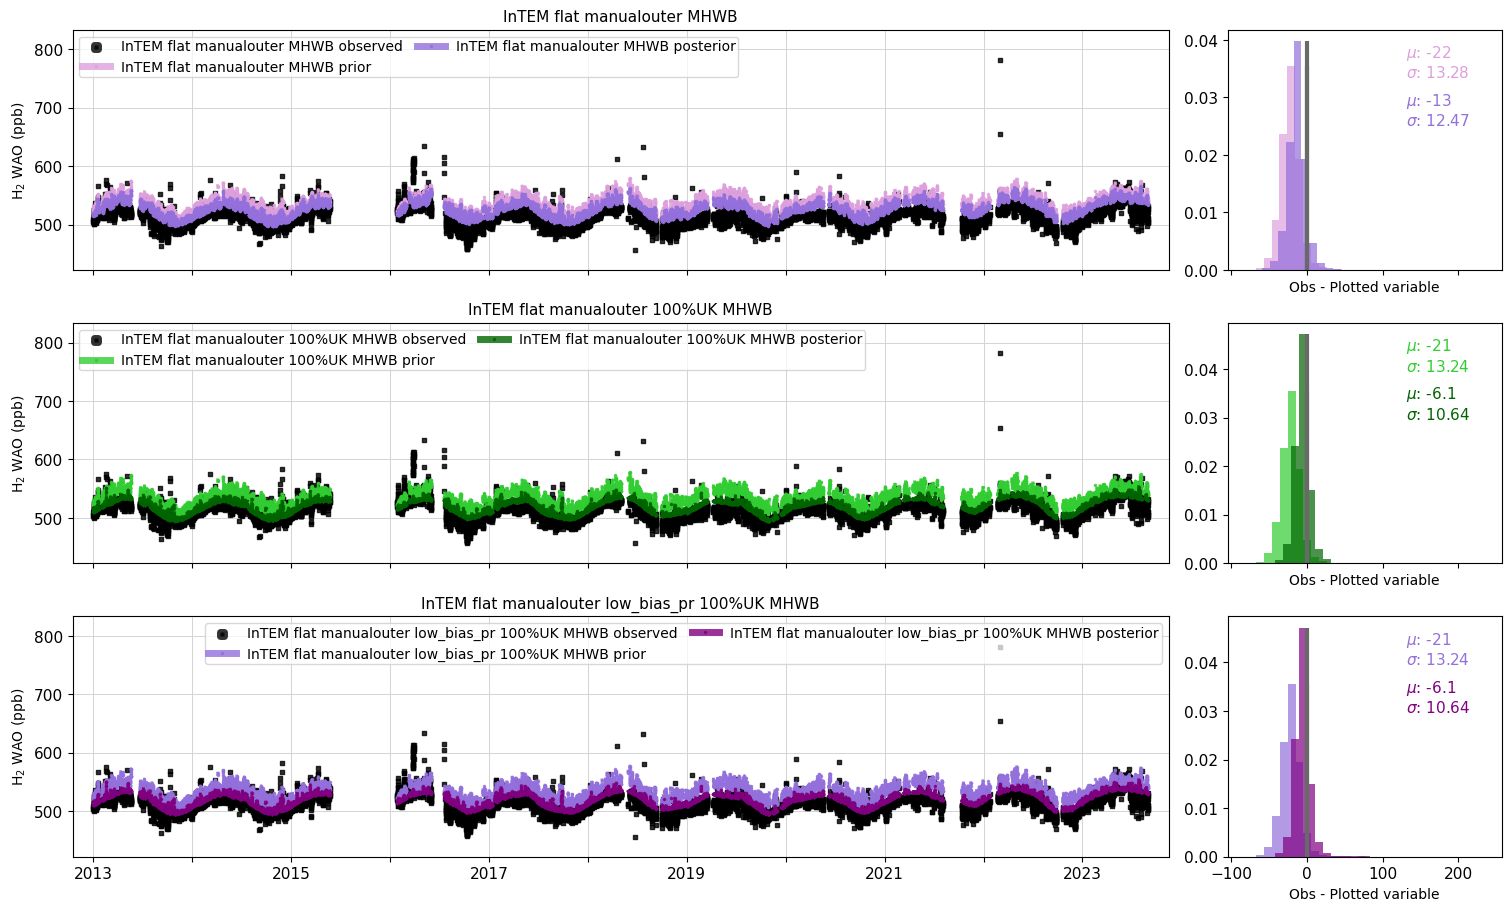

In [4]:
from fluxy.plots.mf_timeseries import plot_timeseries

###################################
### edit variables in this block
# Variables and respective uncertainties to plot
include = {'mf_observed'   : 'stdev_mf_total',
           'mf_prior' : None,
           'mf_posterior' : 'stdev_mf_posterior',
           }

#include = {'stdev_mf_total': None
#           }

# To plot the histogram of the variables in "include", set "diff_include" to None
# To plot the histogram of Obs-variable, set "diff_include" to the desired variable to be subtracted
diff_include = ['mf_prior','mf_posterior']

y_lim = None # to choose y-axis limits set y_lim=[min_value,max_value]
aggreg_month = False # set to true to aggregate mf data by month and see the seasonnal cycle
###################################

###################################
### options for variables to include
# mf_observed         - total observed mole fraction
# mf_prior            - prior total mole fraction
# mf_posterior        - posterior total mole fraction
# mf_bc_prior         - prior baseline
# mf_bc_posterior     - posterior baseline
# mf_bias_prior       - prior bias added to site
# mf_bias_posterior   - posterior bias added to site
# mf_outer_prior      - prior mole fractions only from outer regions
# mf_outer_posterior  - posterior mole fractions only from outer regions
# stdev_mf_observed_repeatability - observed repeatability mole fraction uncertainty
# stdev_mf_observed_variability   - observed variability mole fraction uncertainty
# stdev_mf_model                  - model mole fraction uncertainty
# stdev_mf_total                  - total mole fraction uncertainty

### options for uncertainties to plot as error bars/shaded area
# stdev_mf_observed_repeatability - observed repeatability mole fraction uncertainty
# stdev_mf_observed_variability   - observed variability mole fraction uncertainty
# stdev_mf_model                  - model mole fraction uncertainty
# stdev_mf_total                  - total mole fraction uncertainty
# percentile_mf_prior             - prior mole fraction uncertainty
# percentile_mf_posterior         - posterior mole fraction uncertainty
###################################

fig = plot_timeseries(ds_all_mf_sliced,include,species,site,
                                    model_colors,model_labels,config_data,annotate_coords,presentation_mode,
                                    plot_type='separate',
                                    diff_include=diff_include,
                                    y_lim=y_lim,intake_height=intake_height,aggreg_month=aggreg_month)

Save plot:

In [ ]:
output_path = '/home/users/alice.ramsden/plots/h2/inversions_no_sources_sinks/uncert-total_h2_WAO_2013-2023_flatprior_testing.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, all models together:

In [ ]:
from fluxy.plots.mf_timeseries import plot_timeseries

###################################
### edit variables in this block (see instructions above)
include = {'mf_posterior' : 'percentile_mf_posterior'}
diff_include=['mf_posterior']
y_lim=None
###################################

fig = plot_timeseries(ds_all_mf_sliced,include,species,site,
                                    model_colors,model_labels,config_data,annotate_coords,presentation_mode,
                                    plot_type='together',
                                    diff_include=diff_include,
                                    y_lim=y_lim,intake_height=intake_height)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/mf_posterior_allmodels.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Absolute differences between two models:

In [ ]:
from fluxy.operators.mf import compute_mf_difference
from fluxy.plots.mf_timeseries import plot_timeseries

###################################
### edit variables in this block
models_to_subtract = models[:2] # Models to subtract (must be a list of 2 elements)
include = {'mf_observed': None}        # Variables to plot (dict values must be set to None)
###################################

ds_diff = compute_mf_difference(ds_all_mf_sliced.copy(), models_to_subtract)

fig = plot_timeseries(ds_diff,include,species,site,
                        model_colors,model_labels,config_data,annotate_coords,presentation_mode,
                        plot_type='diff',
                        diff_include=None,
                        y_lim=None,intake_height=intake_height)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/mf_posterior_diff.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Calculate and plot stats for the fit to obs:

In [ ]:
from fluxy.operators.select import slice_mf
from fluxy.operators.mf import stats_mf
from fluxy.plots.mf_stats import plot_stats_mf


###################################
### edit variables in this block
stats_to_plot = ['pearson', 'bias', 'crmse']
what_to_compare = 'posterior_above_BC'
stats_ylim = {"pearson": [0,1], "bias": [-1.5,0.5], "crmse": [0,1.5] }    # or set it to None
get_labels_from_file = True # If False, uses default labels. If True, uses labels from config file.


### Implemented statistics (stats_to_plot)
# pearson - Pearson correlation coefficient
# bias    - Mean difference
# rmse    - RMSE
# nrmse   - Normalised RMSE (division by mean observation)
# crmse   - Centered (bias-corrected) RMSE
# std_obs  - Standard deviation of observations 
# std_sim  - Standard deviation of simulation 
# std_res  - Standard deviation of residuals
# nn      - Number of observation-simulation pairs 
###################################

ds_all_allsites = slice_mf(ds_all_mf.copy(), 
                        start_date,
                        end_date,site=None,
                        baseline_site=baseline_site,
                        baseline_filename=baseline_filename,
                        data_dir=data_dir,
                        mf_units_print=mf_units_print)

model_labels = set_model_labels(models,config_data,get_labels_from_file)

stats = stats_mf(ds_all_allsites, stats_type=what_to_compare)

fig = plot_stats_mf(stats=stats, 
                    stats_to_plot=stats_to_plot, 
                    species=species,
                    model_colors=model_colors, 
                    model_labels=model_labels, 
                    config_data=config_data, 
                    mf_units_print=mf_units_print,
                    stats_type=what_to_compare,
                    stats_ylim=stats_ylim,
                    start_date=start_date, 
                    end_date=end_date)

#### Plot Taylor Diagrams

In [ ]:
from fluxy.operators.mf import stats_mf
from fluxy.plots.mf_stats import plot_taylor_diagram

###################################
### edit variables in this block
include = ['prior','posterior'] # Variables to include in the Taylor diagram
plot_type_model = 'together' #  If 'separate', plots each model in a separate subplot. If 'together', plots all models in the same subplot.
plot_type_stat = 'together'  # If 'separate', plots each statistic in a separate subplot. If 'together', plots all statistics in the same subplot.
normalize = True # If True, normalizes the data by the standard deviation of the observations. If False, plots the absolute data.
stat_markers = ['s'] # Marker styles used to plot the stats specified in the `include` parameter, sharing the same index. 
std_range = [0, 1.5] # Range for the standard deviation axis, in units provided with `std_unit` if `normalize` = True.
check_sites = False # If True, color different sites with different colors
###################################

model_labels = set_model_labels(models, config_data, get_labels_from_file)

stats = {}
for stat in include:
    stats[stat] = stats_mf(ds_all_allsites, stats_type=stat)

fig = plot_taylor_diagram(
    stats=stats,
    model_colors=model_colors,
    model_labels=model_labels,
    stat_markers=stat_markers,
    normalize=normalize,
    plot_type_model=plot_type_model,
    plot_type_stat=plot_type_stat,
    include=include,
    std_range=std_range,
    std_unit=mf_units_print,
    check_sites=check_sites
)

Save plot:

In [ ]:
#output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Spatial maps of country/region fluxes

In [ ]:
from fluxy.io import read_model_output
from fluxy.operators.select import slice_flux
from fluxy.config import set_model_labels
from fluxy.operators.flux_scale_by_sector_proportions import scale_by_sector_proportions

###################################
### edit variables in this block
species = 'h2'
start_date = '2019-01-01' 
end_date = '2023-01-01'
models = ['InTEM_NAME_EUROPE_flatlandsea_MH',
          'InTEM_NAME_EUROPE_flatlandsea_popouterregions_MH',
          'InTEM_NAME_EUROPE_flatlandsea_manualouter_MHWB',
          'InTEM_NAME_EUROPE_flatlandsea_manualouter_100uncertUK_MHWB']
period = 'yearly' # inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
flux_units_print = 'kg km-2 yr-1'
get_labels_from_file = True # If False, uses default labels. If True, uses labels from config file.
add_sites_to_flux = True # If true, add sites variable to flux dataset.
sector_file = None   #if not None, adds sector level results, by scaling model totals by the sector proportions in this file, default 'EUROPE_EDGAR'
sectors = ['total']       #sectors to add to model ds, using sector_proportions_file, options for: ['agriculture','waste','energy','industry']
read_standard_run = False
###################################

ds_all_flux = read_model_output(data_dir, "flux", species, models, config_data, period=period, add_sites_to_flux=add_sites_to_flux, read_standard_run=read_standard_run)

ds_all_flux_scaled = slice_flux(ds_all_flux,config_data,start_date,end_date,species=species,flux_units_print=flux_units_print)

model_labels = set_model_labels(models, config_data, get_labels_from_file)

if sector_file is not None:
    for m in models:
        ds_all_flux_scaled[m] = scale_by_sector_proportions(data_dir=data_dir,ds=ds_all_flux_scaled[m],
                                                            species=species,sectors=sectors,regions=None,
                                                            country_flux_units_print=None,
                                                            config_data=config_data,
                                                            sector_file=sector_file,
                                                            create_region_sector_totals=False)

##### Prior and posterior fluxes comparison across models

In [ ]:
from fluxy.plots.flux_map import plot_flux_map

###################################
### edit variables in this block
region = [-20,50,25,85]
add_sites = True
add_markers = ['london'] # Add a marker at given locations, options for 'paris', 'london', ... or any value [lon, lat]
season = None # If specified, plot the seasonal mean (only valable for monthly data), options for 'DJF', 'MAM', 'JJA' and 'SON'
set_fluxlim = 'auto' # Set flux colorbar limits: e.g.[0,10]|'auto' ('auto' = 99th percentile of flux_posterior)
plot_inversion_grid_flux = True # If True, plot fluxes at inversion's resolution. If False, plot fluxes at prior's resolution.
sector = 'total'     # default 'total', otherwise chosen single sector plotted for all models
include_title_and_labels = True # if False, simplifys plots by removing title, y axis label, lat/lon ticks and some info from cbar label
site_marker = '^'
city_marker = 'o'
marker_color = 'black'
###################################

fig = plot_flux_map(ds_all_flux_scaled, species, region, config_data, model_labels, season=season,
                    add_sites=add_sites, add_markers=add_markers, set_fluxlim=set_fluxlim, 
                    plot_inversion_grid_flux=plot_inversion_grid_flux,sector=sector,
                    include_title_and_labels=include_title_and_labels,city_marker=city_marker,
                    site_marker=site_marker,marker_color=marker_color)

Save plot:

In [ ]:
#output_path = None
#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Flux comparison between two models

In [ ]:
from fluxy.plots.flux_map import plot_flux_map_model_comparison

###################################
### edit variables in this block
models_plot = models[:2]
region = 'FRA'
sector = 'total'     # default 'total', otherwise chosen single sector plotted for all models
var = f'flux_{sector}_posterior_inversion_grid'
###################################

fig = plot_flux_map_model_comparison(ds_all_flux_scaled, var, models_plot, species, region, config_data, model_labels, 
                                     season=season, add_sites=add_sites, add_markers=add_markers, 
                                     set_fluxlim=set_fluxlim,sector=sector)

Save plot:

In [ ]:
#output_path = None
#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Plot prior, posterior or difference fluxes per time interval:

In [ ]:
from fluxy.plots.flux_map import plot_flux_map_over_time

region = 'FRA'
chop_by = 'year' # Time unit of the averaging period (options for 'year', 'month' and 'season').
                 # Alternatively, a list of starting dates can be provided (format '2018-01-01'), a list of months (e.g., [[1:3], [7:9]]), or a tuple of lists of starting_dates and ending_dates (e.g., (['2018-01-01','2022-01-01'], ['2020-01-01','2025-01-01']))
dt = 2  # Number of time steps for year and month chop_by options
plot_combined = False
add_sites = True    
add_markers = ['paris']
set_fluxlim = 'auto' # Set flux colorbar limits: e.g.[0,10]|'auto' ('auto' = 99th percentile of flux_posterior)
sector = 'total'     # default 'total', otherwise chosen single sector plotted for all models
var = f'flux_{sector}_posterior'  # Variable to be plotted. Extra options for 'posterior_prior_diff', 'posterior_mean_diff', 'posterior_prior_diff_inversion_grid', 'posterior_mean_diff_inversion_grid'.
###################################

fig = plot_flux_map_over_time(ds_all_flux_scaled, var, species,region,config_data, model_labels, chop_by=chop_by, dt=dt,
                              plot_combined=plot_combined, add_sites=add_sites, add_markers=add_markers, 
                              set_fluxlim = set_fluxlim,sector=sector)

Save plot:

In [ ]:
#output_path = None
#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Flux comparison between two groups of models

In [ ]:
from fluxy.plots.flux_map import plot_flux_map_combined_models_comparison

###################################
### edit variables in this block
group_a = [models[0], models[1]] # List of model names to be combined for the first group.
group_b = [models[2]] # List of model names to be combined for the second group.
group_a_label = "Group A" # Label for the first group of combined models.
group_b_label = "Group B" # Label for the second group of combined models.
var = "flux_total_posterior_inversion_grid"
region = "FRA"
add_sites = False
add_markers = False
season = None
###################################

fig = plot_flux_map_combined_models_comparison(
    ds_all=ds_all_flux_scaled,
    var=var,
    group_a_models=group_a,
    group_b_models=group_b,
    species=species,
    region=region,
    config_data=config_data,
    group_a_label=group_a_label,
    group_b_label=group_b_label,
    add_sites=add_sites,
    add_markers=add_markers,
    season=season
)

##### Flux comparison between two periods

In [ ]:
from fluxy.plots.flux_map import plot_flux_map_period_comparison

region = 'UK'
start_dates = ['2015-01-01', '2022-01-01'] # List of start dates for the two periods to compare
end_dates = ['2018-01-01', '2025-01-01'] # List of end dates for the two periods to compare
plot_combined = False 
add_sites = True    
add_markers = None
set_fluxlim = 'auto' # Set flux colorbar limits: e.g.[0,10]|'auto' ('auto' = 99th percentile of flux_posterior)
set_fluxlim_percentile = 0.99
var = 'flux_total_posterior_inversion_grid'  # Variable to be plotted. Extra options for 'posterior_prior_diff', 'posterior_mean_diff', 'posterior_prior_diff_inversion_grid', 'posterior_mean_diff_inversion_grid'.
###################################

fig = plot_flux_map_period_comparison(
                                ds_all_flux_scaled, 
                                var, 
                                species,
                                start_dates,
                                end_dates,
                                region,
                                config_data, 
                                model_labels, 
                                plot_combined=plot_combined, 
                                add_sites=add_sites, 
                                add_markers=add_markers, 
                                set_fluxlim = set_fluxlim, 
                                set_fluxlim_percentile=set_fluxlim_percentile)

### 4. Timeseries of country fluxes - stacked bar chart of all species

In [ ]:
from fluxy.io import read_model_output, read_flux_total_fgases
from fluxy.operators.select import slice_flux
from fluxy.plots.flux_timeseries import plot_all_species_stacked_bar

###################################
### edit variables in this block
all_species = ['nf3','sf6','all_pfc','all_hfc','n2o','ch4']
period = ['yearly','yearly','yearly','yearly','monthly','monthly'] #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
models = ['InTEM']
regions = 'GBR'
country_flux_units_print = 'Tg CO2-eq yr-1' #desired units for the plot. Add "CO2-eq" to convert the mass to CO2 equivalent (e.g. "Gg CO2-eq yr-1")
start_date = '2018-01-01' #inclusive
end_date = '2024-01-01' #not inclusive
get_labels_from_file = False # If False, uses default labels. If True, uses labels in models_info.json.
sector_file = None  # if not None, adds sector level results by scaling model totals by the sector proportions in this file.
create_region_sector_totals = False #if True, uses country_fraction variable to sum spatial sector fluxes to region sector fluxes
read_standard_run = True
only_overlapping = True #if True, only uses time periods where all models have data
###################################

ds_all_flux = {}
ds_all_flux_scaled = {}

for s,species in enumerate(all_species):
    if 'all' in species:
        ds_all_flux_scaled[species] = read_flux_total_fgases(data_dir,species,models,config_data,
                                                         regions,start_date,end_date,
                                                         period=period[s],only_overlapping=only_overlapping)
    else:
        ds_all_flux[species] = read_model_output(data_dir,"flux",species,models,config_data,period=period[s],read_standard_run=read_standard_run)
        ds_all_flux_scaled[species] = slice_flux(ds_all_flux[species],config_data,start_date,end_date,species=species,country_flux_units_print=country_flux_units_print)
        


#### Stacked bar chart of all species, for one model

In [ ]:
###################################
### edit variables in this block
y_lim = None

plot_inventory_uncertainty = True
inventory_years = ['2025']
inventory_filename = 'UNFCCC_inventory'
###################################

fig = plot_all_species_stacked_bar(all_species=all_species,
                                      ds_all_flux_scaled=ds_all_flux_scaled,
                                      regions=regions,
                                      config_data=config_data,
                                      model_colors=model_colors,
                                      model_labels=model_labels,
                                      start_date=start_date,
                                      end_date=end_date,
                                      plot_inventory_uncertainty=plot_inventory_uncertainty,
                                      inventory_years=inventory_years,
                                      inventory_filename=inventory_filename,
                                      data_dir=data_dir,
                                      y_lim=y_lim)